#Classification Model
This notebook builds and evaluates an XGBoost classification model to predict lithology classes from well-log measurements. It follows the workflow from loading and cleaning the data through feature engineering, validation, testing, and feature-importance analysis.


## Data Cleaning
This section prepares the raw well-log data for modeling. It loads the files, inspects their structure, creates the target labels, splits wells into training and test sets, removes unsuitable columns or rows, and interpolates missing `DRHO` values within each well.


### Load the data
The following cells connect Google Colab to Google Drive and combine all CSV files at the specified path into one DataFrame named `df_clssification`. Confirm that the Drive path and training-data files are available before running them.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from google.colab import files
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
files = glob.glob('/content/drive/MyDrive/Force_2020_all_wells_train_test_blind_hidden_final- Training Data/*.csv')
df_clssification = pd.concat([pd.read_csv(f) for f in files])

Mounted at /content/drive


### Quick look at the data
These checks show the DataFrame's columns, data types, missing-value counts, descriptive statistics, and feature distributions. Use them to understand the raw data and spot values that may require cleaning.


In [ ]:
df_clssification.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2337639 entries, 0 to 19691
Data columns (total 29 columns):
 #   Column                             Dtype  
---  ------                             -----  
 0   source_file                        object 
 1   well_name                          object 
 2   DEPT                               float64
 3   FORCE_2020_LITHOFACIES_CONFIDENCE  float64
 4   FORCE_2020_LITHOFACIES_LITHOLOGY   float64
 5   CALI                               float64
 6   BS                                 float64
 7   MUDWEIGHT                          float64
 8   ROP                                float64
 9   RDEP                               float64
 10  RSHA                               float64
 11  RMED                               float64
 12  SP                                 float64
 13  DTC                                float64
 14  NPHI                               float64
 15  GR                                 float64
 16  RHOB                     

In [ ]:
df_clssification.describe()

,DEPT,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,CALI,BS,MUDWEIGHT,ROP,RDEP,RSHA,RMED,...,X_LOC,Y_LOC,Z_LOC,DCAL,ROPA,DTS,PEF,RXO,RMIC,SGR
count,2.337639e+06,1.444053e+06,1.431383e+06,1.461913e+06,1.456879e+06,439700.000000,1.220926e+06,2.219193e+06,868460.000000,2.092874e+06,...,2.221893e+06,2.221893e+06,2.221893e+06,384238.000000,738753.000000,388821.000000,924140.000000,386207.000000,238377.000000,72163.000000
mean,1.876127e+03,1.153701e+00,6.142501e+04,1.323380e+01,1.377952e+01,7.609570,3.268063e+02,8.484874e+00,9.953705,4.351024e+00,...,4.850926e+05,6.691335e+06,-1.873012e+03,16.402556,36.193849,221.196730,6.279848,-100.804748,9.230063,62.730798
std,1.062783e+03,4.331476e-01,1.397315e+04,3.714703e+00,5.013730e+00,34.019752,3.022932e+03,9.085895e+01,96.699936,5.298681e+01,...,3.556914e+04,1.356244e+05,1.015253e+03,394.248043,84.974114,81.475537,10.679024,364.144671,106.653605,52.769761
min,4.880000e-02,1.000000e+00,3.000000e+04,2.340806e+00,6.000000e+00,0.124619,-2.149578e+01,1.000000e-04,0.000100,-8.418695e-03,...,4.232375e+05,6.406641e+06,-5.435889e+03,-23.199656,-999.250122,69.163177,0.000100,-999.900024,0.056586,-983.000000
25%,1.006690e+03,1.000000e+00,6.500000e+04,9.893431e+00,9.875000e+00,0.141395,1.109909e+01,9.293004e-01,0.835767,9.068966e-01,...,4.544695e+05,6.571042e+06,-2.603980e+03,0.099748,15.052600,160.311493,3.409962,0.663425,0.883667,42.073429
50%,1.764242e+03,1.000000e+00,6.500000e+04,1.256316e+01,1.225000e+01,0.161766,2.562489e+01,1.413411e+00,1.344424,1.373871e+00,...,4.787689e+05,6.758510e+06,-1.771354e+03,0.468299,25.744751,200.151916,4.364290,1.335758,1.638852,68.817604
75%,2.624239e+03,1.000000e+00,6.500000e+04,1.649786e+01,1.750000e+01,1.150334,4.305305e+01,2.321915e+00,2.606366,2.259552e+00,...,5.201532e+05,6.798584e+06,-1.047976e+03,1.186321,38.867996,258.840820,6.003446,3.186819,4.096697,87.497753
max,5.479040e+03,3.000000e+00,9.900000e+04,3.211106e+01,4.200000e+01,426.921356,9.242916e+04,1.999997e+03,2193.904541,1.999948e+03,...,5.726328e+05,6.856661e+06,-7.265216e+01,10023.759766,3989.174316,724.536194,383.129974,35930.671875,10000.000000,963.608582


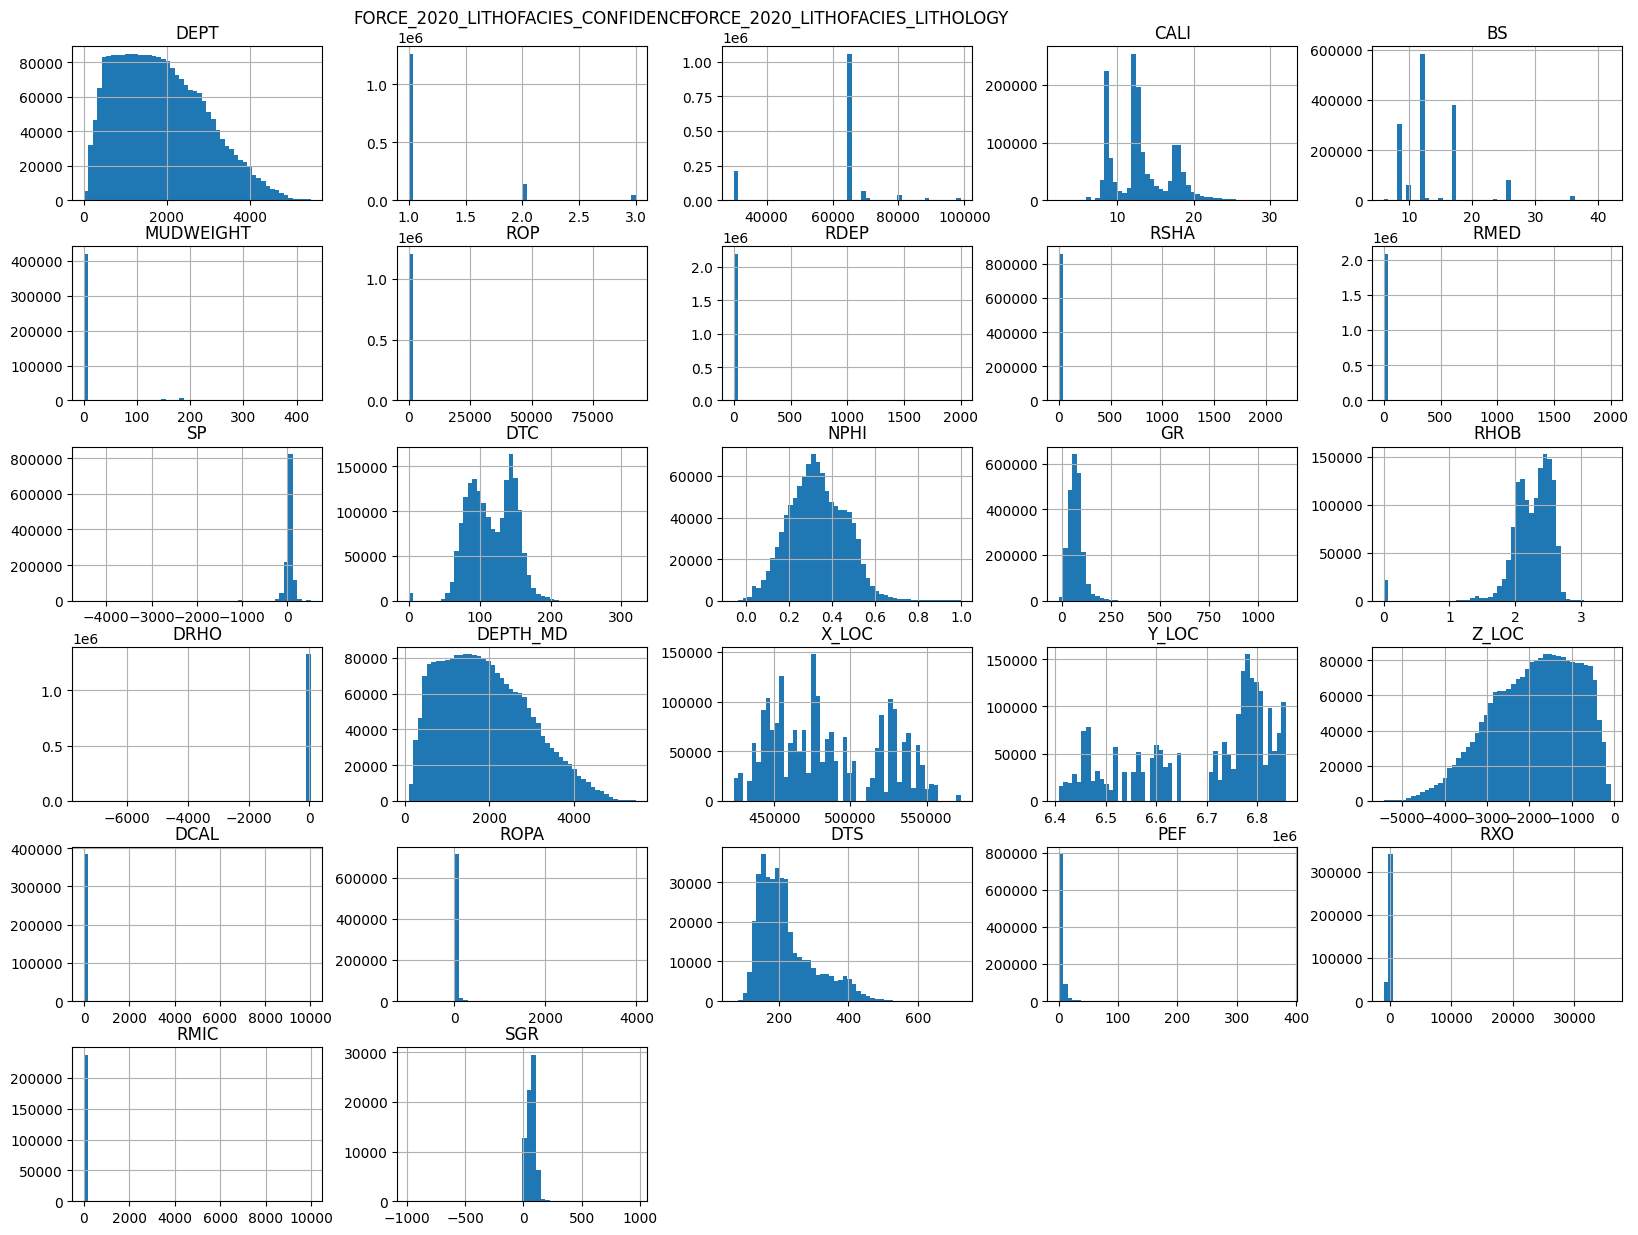

In [ ]:
df_clssification.hist(bins=50, figsize=(20, 15))
plt.show()

### Spliting the data
The data is sorted by well and depth, converted from lithology codes to the three target classes (Sandstone, Shale, and Limestone), and encoded as integers. Entire wells—not individual rows—are then assigned to training or testing, which helps prevent data leakage between the two sets.


In [ ]:
df_clssification = df_clssification.sort_values(
    ['well_name', 'DEPT']
).reset_index(drop=True)

In [ ]:
mapping = {
    30000: "Sandstone",
    65000: "Shale",
    70000: "Limestone"
}

df_clssification["Lithology"] = df_clssification["FORCE_2020_LITHOFACIES_LITHOLOGY"].map(mapping)
df_clssification = df_clssification.dropna(subset=["Lithology"])
print(df_clssification["Lithology"].value_counts())

Lithology
Shale        877043
Sandstone    207704
Limestone     69498
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()
df_clssification["Lithology"] = le.fit_transform(df_clssification["Lithology"])

In [ ]:
for i, label in enumerate(le.classes_):
    print(i, "->", label)

0 -> Limestone
1 -> Sandstone
2 -> Shale


In [ ]:
wells = df_clssification["well_name"].unique()
rng = np.random.default_rng(42)
wells_shuffled = rng.permutation(wells)
n_test = int(len(wells_shuffled) * 0.2)
RandomWells = wells_shuffled[:n_test]
TrainDf_classification = df_clssification[~df_clssification["well_name"].isin(RandomWells)]
TestDf_classification = df_clssification[df_clssification["well_name"].isin(RandomWells)]

In [ ]:
wells_to_remove = ['25/11-24 Jakob South', '34/12-1']
TrainDf_classification = TrainDf_classification[~TrainDf_classification["well_name"].isin(wells_to_remove)].copy()
TestDf_classification = TestDf_classification[~TestDf_classification["well_name"].isin(wells_to_remove)].copy()


In [ ]:
if "Lithology" in TrainDf_classification.columns:
    print("exit")
else:
    print("not exit")

exit


In [ ]:
TrainDf_classification.columns

Index(['source_file', 'well_name', 'DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE',
       'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'BS', 'MUDWEIGHT', 'ROP',
       'RDEP', 'RSHA', 'RMED', 'SP', 'DTC', 'NPHI', 'GR', 'RHOB', 'DRHO',
       'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'DCAL', 'ROPA', 'DTS', 'PEF',
       'RXO', 'RMIC', 'SGR', 'Lithology'],
      dtype='object')

In [ ]:
TrainDf_classification.shape , TestDf_classification.shape

((889755, 30), (254628, 30))

###Remove garbige
This part measures missingness, drops selected log columns, requires a core set of available measurements, and interpolates `DRHO` separately inside each well. The same transformations are applied to training and test data to keep their structure consistent.


In [ ]:
percentagesNulls= TrainDf_classification.isnull().sum()/ len(TrainDf_classification)*100
print(percentagesNulls.sort_values(ascending=False))

SGR                                  97.264865
RMIC                                 85.352148
MUDWEIGHT                            79.832089
DTS                                  78.840355
DCAL                                 76.491394
ROPA                                 75.698479
RXO                                  73.710516
ROP                                  53.146878
RSHA                                 50.534810
PEF                                  41.379930
BS                                   39.853106
NPHI                                 33.222516
SP                                   33.088097
DRHO                                 16.174228
RHOB                                 13.526645
CALI                                  7.603666
DTC                                   7.409680
RMED                                  2.456856
RDEP                                  0.402358
X_LOC                                 0.384937
DEPTH_MD                              0.384937
Y_LOC        

In [ ]:
cols_to_drop = [
    'SGR',
    'RMIC',
    'MUDWEIGHT',
    'DCAL',
    'RXO',
    'DTS',
    'ROPA',
    'ROP',
    'SP',
    'RSHA'
]

TrainDf_classification = TrainDf_classification.drop(columns=cols_to_drop, errors='ignore')
TestDf_classification = TestDf_classification.drop(columns=cols_to_drop, errors='ignore')


In [ ]:
core_required = ['CALI', 'RDEP', 'DTC', 'RHOB', 'NPHI']
TrainDf_classification.dropna(subset=["GR"]+ core_required, inplace=True)
print('rows after requiring core log suite:', len(TrainDf_classification))

rows after requiring core log suite: 534304


In [ ]:
core_required = ['CALI', 'RDEP', 'DTC', 'RHOB', 'NPHI']
TestDf_classification.dropna(subset=["GR"]+ core_required, inplace=True)
print('rows after requiring core log suite:', len(TestDf_classification))

rows after requiring core log suite: 171472


In [ ]:
TrainDf_classification['DRHO'] = (
    TrainDf_classification.groupby('well_name')['DRHO']
    .transform(lambda x: x.interpolate())
)

#---
TestDf_classification['DRHO'] = (
    TestDf_classification.groupby('well_name')['DRHO']
    .transform(lambda x: x.interpolate()))

### feature engineering
New features are created from the available logs, including borehole-enlargement indicators, log ratios, relative depth, rolling mean and standard-deviation features, gradients, and frequency encodings for geological groups and formations. These transformations are applied to both training and test data.


In [ ]:
import numpy as np
import pandas as pd


def add_washout_features(TrainDf_classification: pd.DataFrame) -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.copy()
    TrainDf_classification["CALI_BS_DIFF"] = TrainDf_classification["CALI"] - TrainDf_classification["BS"]
    TrainDf_classification["IS_WASHOUT"] = (TrainDf_classification["CALI_BS_DIFF"] > 2).astype(int)
    return TrainDf_classification


def add_ratio_features(TrainDf_classification: pd.DataFrame) -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.copy()
    eps = 1e-6

    if {"RHOB", "NPHI"}.issubset(TrainDf_classification.columns):
        TrainDf_classification["RHOB_NPHI_DIFF"] = TrainDf_classification["RHOB"] - TrainDf_classification["NPHI"]

    if {"RDEP", "RMED"}.issubset(TrainDf_classification.columns):
        TrainDf_classification["RES_RATIO"] = TrainDf_classification["RDEP"] / (TrainDf_classification["RMED"] + eps)
        TrainDf_classification["LOG_RDEP"] = np.log1p(TrainDf_classification["RDEP"].clip(lower=0))
        TrainDf_classification["LOG_RMED"] = np.log1p(TrainDf_classification["RMED"].clip(lower=0))

    if {"DTC", "RHOB"}.issubset(TrainDf_classification.columns):
        TrainDf_classification["DTC_RHOB_PROD"] = TrainDf_classification["DTC"] * TrainDf_classification["RHOB"]

    if "PEF" in TrainDf_classification.columns and "RHOB" in TrainDf_classification.columns:
        TrainDf_classification["PEF_RHOB_RATIO"] = TrainDf_classification["PEF"] / (TrainDf_classification["RHOB"] + eps)

    return TrainDf_classification


def add_rolling_features(
    TrainDf_classification: pd.DataFrame,
    cols: list,
    well_col: str = "well_name",
    depth_col: str = "DEPTH_MD",
    windows: list = (5, 15, 31),
) -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.sort_values([well_col, depth_col]).copy()
    grouped = TrainDf_classification.groupby(well_col)

    for col in cols:
        if col not in TrainDf_classification.columns:
            continue
        for w in windows:
            TrainDf_classification[f"{col}_ROLLMEAN_{w}"] = grouped[col].transform(
                lambda s: s.rolling(w, min_periods=1).mean()
            )
            TrainDf_classification[f"{col}_ROLLSTD_{w}"] = grouped[col].transform(
                lambda s: s.rolling(w, min_periods=1).std()
            )

    return TrainDf_classification


def add_gradient_features(
    TrainDf_classification: pd.DataFrame,
    cols: list,
    well_col: str = "well_name",
    depth_col: str = "DEPTH_MD",
) -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.sort_values([well_col, depth_col]).copy()
    grouped = TrainDf_classification.groupby(well_col)

    for col in cols:
        if col not in TrainDf_classification.columns:
            continue
        TrainDf_classification[f"{col}_GRAD"] = grouped[col].transform(lambda s: s.diff().fillna(0))

    return TrainDf_classification


def add_depth_features(TrainDf_classification: pd.DataFrame, well_col: str = "well_name", depth_col: str = "DEPTH_MD") -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.copy()
    well_min = TrainDf_classification.groupby(well_col)[depth_col].transform("min")
    well_max = TrainDf_classification.groupby(well_col)[depth_col].transform("max")
    span = (well_max - well_min).replace(0, np.nan)
    TrainDf_classification["DEPTH_REL"] = ((TrainDf_classification[depth_col] - well_min) / span).fillna(0)
    return TrainDf_classification


def add_group_formation_encoding(
    TrainDf_classification: pd.DataFrame,
    train_reference_df: pd.DataFrame,
    cat_cols: list = ("GROUP", "FORMATION"),
) -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.copy()
    for col in cat_cols:
        if col not in TrainDf_classification.columns:
            continue
        freq_map = train_reference_df[col].value_counts(normalize=True)
        TrainDf_classification[f"{col}_FREQ"] = TrainDf_classification[col].map(freq_map).fillna(0)
    return TrainDf_classification


def build_features(TrainDf_classification: pd.DataFrame, train_reference_df: pd.DataFrame = None) -> pd.DataFrame:
    out = TrainDf_classification.copy()
    out = add_washout_features(out)
    out = add_ratio_features(out)
    out = add_depth_features(out)
    out = add_rolling_features(out, cols=["RHOB", "NPHI", "DTC", "CALI", "PEF"])
    out = add_gradient_features(out, cols=["RHOB", "NPHI", "DTC", "CALI"])

    ref_df = train_reference_df if train_reference_df is not None else out
    out = add_group_formation_encoding(out, ref_df)

    return out

In [ ]:
TrainDf_classification = build_features(TrainDf_classification, train_reference_df=TrainDf_classification)

print(TrainDf_classification.shape)
print(TrainDf_classification.columns.tolist())
TrainDf_classification.head()

(534304, 63)
['source_file', 'well_name', 'DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'BS', 'RDEP', 'RMED', 'DTC', 'NPHI', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'PEF', 'Lithology', 'CALI_BS_DIFF', 'IS_WASHOUT', 'RHOB_NPHI_DIFF', 'RES_RATIO', 'LOG_RDEP', 'LOG_RMED', 'DTC_RHOB_PROD', 'PEF_RHOB_RATIO', 'DEPTH_REL', 'RHOB_ROLLMEAN_5', 'RHOB_ROLLSTD_5', 'RHOB_ROLLMEAN_15', 'RHOB_ROLLSTD_15', 'RHOB_ROLLMEAN_31', 'RHOB_ROLLSTD_31', 'NPHI_ROLLMEAN_5', 'NPHI_ROLLSTD_5', 'NPHI_ROLLMEAN_15', 'NPHI_ROLLSTD_15', 'NPHI_ROLLMEAN_31', 'NPHI_ROLLSTD_31', 'DTC_ROLLMEAN_5', 'DTC_ROLLSTD_5', 'DTC_ROLLMEAN_15', 'DTC_ROLLSTD_15', 'DTC_ROLLMEAN_31', 'DTC_ROLLSTD_31', 'CALI_ROLLMEAN_5', 'CALI_ROLLSTD_5', 'CALI_ROLLMEAN_15', 'CALI_ROLLSTD_15', 'CALI_ROLLMEAN_31', 'CALI_ROLLSTD_31', 'PEF_ROLLMEAN_5', 'PEF_ROLLSTD_5', 'PEF_ROLLMEAN_15', 'PEF_ROLLSTD_15', 'PEF_ROLLMEAN_31', 'PEF_ROLLSTD_31', 'RHOB_GRAD', 'NPHI_GRAD', 'DTC_GRAD', 'CALI_GRAD']


,source_file,well_name,DEPT,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,CALI,BS,RDEP,RMED,DTC,...,PEF_ROLLMEAN_5,PEF_ROLLSTD_5,PEF_ROLLMEAN_15,PEF_ROLLSTD_15,PEF_ROLLMEAN_31,PEF_ROLLSTD_31,RHOB_GRAD,NPHI_GRAD,DTC_GRAD,CALI_GRAD
23953,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-14,480.628001,NaN,65000.0,19.2031,NaN,1.513937,1.613886,174.347092,...,55.815659,NaN,55.815659,NaN,55.815659,NaN,0.000000,0.000000,0.000000,0.0
23954,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-14,480.780001,NaN,65000.0,19.2031,NaN,1.480188,1.574376,176.112915,...,48.839098,9.866347,48.839098,9.866347,48.839098,9.866347,0.000667,-0.004009,1.765823,0.0
23955,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-14,480.932001,1.0,65000.0,19.2031,NaN,1.469700,1.436627,177.662476,...,45.422023,9.148859,45.422023,9.148859,45.422023,9.148859,-0.010537,0.004274,1.549561,0.0
23956,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-14,481.084001,1.0,65000.0,19.2031,NaN,1.469341,1.276094,177.437714,...,44.421017,7.733636,44.421017,7.733636,44.421017,7.733636,-0.009356,0.000671,-0.224762,0.0
23957,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-14,481.236001,1.0,65000.0,19.2031,NaN,1.466462,1.204704,176.797653,...,45.431061,7.068082,45.431061,7.068082,45.431061,7.068082,-0.008937,0.014279,-0.640060,0.0


In [ ]:
import numpy as np
import pandas as pd


def add_washout_features(TestDf_classification: pd.DataFrame) -> pd.DataFrame:
    TestDf_classification = TestDf_classification.copy()
    TestDf_classification["CALI_BS_DIFF"] = TestDf_classification["CALI"] - TestDf_classification["BS"]
    TestDf_classification["IS_WASHOUT"] = (TestDf_classification["CALI_BS_DIFF"] > 2).astype(int)
    return TestDf_classification


def add_ratio_features(TestDf_classification: pd.DataFrame) -> pd.DataFrame:
    TestDf_classification = TestDf_classification.copy()
    eps = 1e-6

    if {"RHOB", "NPHI"}.issubset(TestDf_classification.columns):
        TestDf_classification["RHOB_NPHI_DIFF"] = TestDf_classification["RHOB"] - TestDf_classification["NPHI"]

    if {"RDEP", "RMED"}.issubset(TestDf_classification.columns):
        TestDf_classification["RES_RATIO"] = TestDf_classification["RDEP"] / (TestDf_classification["RMED"] + eps)
        TestDf_classification["LOG_RDEP"] = np.log1p(TestDf_classification["RDEP"].clip(lower=0))
        TestDf_classification["LOG_RMED"] = np.log1p(TestDf_classification["RMED"].clip(lower=0))

    if {"DTC", "RHOB"}.issubset(TestDf_classification.columns):
        TestDf_classification["DTC_RHOB_PROD"] = TestDf_classification["DTC"] * TestDf_classification["RHOB"]

    if "PEF" in TestDf_classification.columns and "RHOB" in TestDf_classification.columns:
        TestDf_classification["PEF_RHOB_RATIO"] = TestDf_classification["PEF"] / (TestDf_classification["RHOB"] + eps)

    return TestDf_classification


def add_rolling_features(
    TestDf_classification: pd.DataFrame,
    cols: list,
    well_col: str = "well_name",
    depth_col: str = "DEPTH_MD",
    windows: list = (5, 15, 31),
) -> pd.DataFrame:
    TestDf_classification = TestDf_classification.sort_values([well_col, depth_col]).copy()
    grouped = TestDf_classification.groupby(well_col)

    for col in cols:
        if col not in TestDf_classification.columns:
            continue
        for w in windows:
            TestDf_classification[f"{col}_ROLLMEAN_{w}"] = grouped[col].transform(
                lambda s: s.rolling(w, min_periods=1).mean()
            )
            TestDf_classification[f"{col}_ROLLSTD_{w}"] = grouped[col].transform(
                lambda s: s.rolling(w, min_periods=1).std()
            )

    return TestDf_classification


def add_gradient_features(
    TestDf_classification: pd.DataFrame,
    cols: list,
    well_col: str = "well_name",
    depth_col: str = "DEPTH_MD",
) -> pd.DataFrame:
    TestDf_classification = TestDf_classification.sort_values([well_col, depth_col]).copy()
    grouped = TestDf_classification.groupby(well_col)

    for col in cols:
        if col not in TestDf_classification.columns:
            continue
        TestDf_classification[f"{col}_GRAD"] = grouped[col].transform(lambda s: s.diff().fillna(0))

    return TestDf_classification


def add_depth_features(TestDf_classification: pd.DataFrame, well_col: str = "well_name", depth_col: str = "DEPTH_MD") -> pd.DataFrame:
    TestDf_classification = TestDf_classification.copy()
    well_min = TestDf_classification.groupby(well_col)[depth_col].transform("min")
    well_max = TestDf_classification.groupby(well_col)[depth_col].transform("max")
    span = (well_max - well_min).replace(0, np.nan)
    TestDf_classification["DEPTH_REL"] = ((TestDf_classification[depth_col] - well_min) / span).fillna(0)
    return TestDf_classification


def add_group_formation_encoding(
    TestDf_classification: pd.DataFrame,
    train_reference_df: pd.DataFrame,
    cat_cols: list = ("GROUP", "FORMATION"),
) -> pd.DataFrame:
    TestDf_classification = TestDf_classification.copy()
    for col in cat_cols:
        if col not in TestDf_classification.columns:
            continue
        freq_map = train_reference_df[col].value_counts(normalize=True)
        TestDf_classification[f"{col}_FREQ"] = TestDf_classification[col].map(freq_map).fillna(0)
    return TestDf_classification


def build_features(TestDf_classification: pd.DataFrame, train_reference_df: pd.DataFrame = None) -> pd.DataFrame:
    out = TestDf_classification.copy()
    out = add_washout_features(out)
    out = add_ratio_features(out)
    out = add_depth_features(out)
    out = add_rolling_features(out, cols=["RHOB", "NPHI", "DTC", "CALI", "PEF"])
    out = add_gradient_features(out, cols=["RHOB", "NPHI", "DTC", "CALI"])

    ref_df = train_reference_df if train_reference_df is not None else out
    out = add_group_formation_encoding(out, ref_df)

    return out

In [ ]:
TestDf_classification = build_features(TestDf_classification, train_reference_df=TestDf_classification)

print(TestDf_classification.shape)
print(TestDf_classification.columns.tolist())
TestDf_classification.head()

(171472, 63)
['source_file', 'well_name', 'DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'BS', 'RDEP', 'RMED', 'DTC', 'NPHI', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'PEF', 'Lithology', 'CALI_BS_DIFF', 'IS_WASHOUT', 'RHOB_NPHI_DIFF', 'RES_RATIO', 'LOG_RDEP', 'LOG_RMED', 'DTC_RHOB_PROD', 'PEF_RHOB_RATIO', 'DEPTH_REL', 'RHOB_ROLLMEAN_5', 'RHOB_ROLLSTD_5', 'RHOB_ROLLMEAN_15', 'RHOB_ROLLSTD_15', 'RHOB_ROLLMEAN_31', 'RHOB_ROLLSTD_31', 'NPHI_ROLLMEAN_5', 'NPHI_ROLLSTD_5', 'NPHI_ROLLMEAN_15', 'NPHI_ROLLSTD_15', 'NPHI_ROLLMEAN_31', 'NPHI_ROLLSTD_31', 'DTC_ROLLMEAN_5', 'DTC_ROLLSTD_5', 'DTC_ROLLMEAN_15', 'DTC_ROLLSTD_15', 'DTC_ROLLMEAN_31', 'DTC_ROLLSTD_31', 'CALI_ROLLMEAN_5', 'CALI_ROLLSTD_5', 'CALI_ROLLMEAN_15', 'CALI_ROLLSTD_15', 'CALI_ROLLMEAN_31', 'CALI_ROLLSTD_31', 'PEF_ROLLMEAN_5', 'PEF_ROLLSTD_5', 'PEF_ROLLMEAN_15', 'PEF_ROLLSTD_15', 'PEF_ROLLMEAN_31', 'PEF_ROLLSTD_31', 'RHOB_GRAD', 'NPHI_GRAD', 'DTC_GRAD', 'CALI_GRAD']


,source_file,well_name,DEPT,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,CALI,BS,RDEP,RMED,DTC,...,PEF_ROLLMEAN_5,PEF_ROLLSTD_5,PEF_ROLLMEAN_15,PEF_ROLLSTD_15,PEF_ROLLMEAN_31,PEF_ROLLSTD_31,RHOB_GRAD,NPHI_GRAD,DTC_GRAD,CALI_GRAD
7327,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-13 Sleipner East Appr,1138.704,1.0,30000.0,19.322735,NaN,1.091499,1.013309,147.837677,...,1.631495,NaN,1.631495,NaN,1.631495,NaN,0.000000,0.000000,0.000000,0.000000
7328,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-13 Sleipner East Appr,1138.856,1.0,65000.0,18.613674,NaN,1.122706,1.088184,142.382431,...,1.638288,0.009606,1.638288,0.009606,1.638288,0.009606,0.026360,0.034395,-5.455246,-0.709061
7329,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-13 Sleipner East Appr,1139.008,1.0,65000.0,18.212072,NaN,1.148141,1.127155,138.258331,...,1.640816,0.008082,1.640816,0.008082,1.640816,0.008082,0.016710,-0.034305,-4.124100,-0.401602
7330,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-13 Sleipner East Appr,1139.160,1.0,65000.0,18.134182,NaN,1.170984,1.141467,139.198914,...,1.635666,0.012232,1.635666,0.012232,1.635666,0.012232,0.011637,-0.063436,0.940582,-0.077890
7331,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-13 Sleipner East Appr,1139.312,1.0,65000.0,18.033762,NaN,1.184080,1.138007,144.290085,...,1.609504,0.059453,1.609504,0.059453,1.609504,0.059453,-0.015480,-0.062813,5.091171,-0.100420


## Building the model
Features are separated from the lithology target and an XGBoost classifier is configured. Its performance is first estimated with grouped cross-validation, which keeps samples from any one well together, before the final model is trained on all training data.


In [ ]:
X_classification= TrainDf_classification.drop(columns=["Lithology", "well_name", "source_file" , "FORCE_2020_LITHOFACIES_LITHOLOGY"], errors='ignore')
Y_classification = TrainDf_classification["Lithology"]
groups_classification= TrainDf_classification["well_name"]

In [ ]:
ClassificationModel= XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.05, n_jobs=-1, random_state=42)
# ClassificationModel.fit(X_classification, Y_classification)

In [ ]:
scores= cross_val_score(
    ClassificationModel,
    X_classification,
    Y_classification,
    groups= groups_classification,
    cv=GroupKFold(n_splits=4),
    scoring= "f1_macro"
)

KeyboardInterrupt: 

In [ ]:
scores

### Test on testing data
The fitted classifier is saved together with the label encoder, then used to predict the held-out wells. The following cells report precision, recall, F1 scores, and a confusion matrix to assess classification performance.


In [ ]:
ClassificationModel= XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.05, n_jobs=-1, random_state=42)
ClassificationModel.fit(X_classification, Y_classification)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
Xtest_classification= TestDf_classification.drop(columns=["Lithology", "well_name", "source_file" , "FORCE_2020_LITHOFACIES_LITHOLOGY"], errors='ignore')
Ytest_classification= TestDf_classification["Lithology"]

In [ ]:
y_pred = ClassificationModel.predict(Xtest_classification)
condusionmatrix=confusion_matrix(Ytest_classification, y_pred)

In [ ]:
Report= classification_report(Ytest_classification, y_pred)
print(Report)

              precision    recall  f1-score   support

           0       0.83      0.75      0.79     11734
           1       0.84      0.84      0.84     25521
           2       0.96      0.97      0.96    134217

    accuracy                           0.93    171472
   macro avg       0.88      0.85      0.86    171472
weighted avg       0.93      0.93      0.93    171472



In [ ]:
print(Y_classification.unique())

[2 1 0]


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(Ytest_classification, y_pred, cmap="Blues")
plt.show()

### Feature importance
This final step ranks the engineered input features by their importance in the trained XGBoost model. The ranking helps identify which measurements influenced predictions most, but it should not be interpreted as proof of causation.


In [ ]:
importance= pd.DataFrame({

"feature": Xtest_classification.columns,
"importance": ClassificationModel.feature_importances_
})
importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance)

                              feature  importance
7                                NPHI    0.134432
8                                  GR    0.115348
9                                RHOB    0.059434
31                    NPHI_ROLLMEAN_5    0.056561
3                                  BS    0.047969
43                    CALI_ROLLMEAN_5    0.043597
21                           LOG_RMED    0.043575
14                              Z_LOC    0.036429
22                      DTC_RHOB_PROD    0.033945
0                                DEPT    0.032025
25                    RHOB_ROLLMEAN_5    0.029523
12                              X_LOC    0.023539
5                                RMED    0.018849
38                      DTC_ROLLSTD_5    0.018181
13                              Y_LOC    0.017998
16                       CALI_BS_DIFF    0.014015
20                           LOG_RDEP    0.013804
33                   NPHI_ROLLMEAN_15    0.013406
2                                CALI    0.012094


In [ ]:
import matplotlib.pyplot as plt

top10 = importance.sort_values(
    by="importance",
    ascending=False
).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top10["feature"][::-1], top10["importance"][::-1])

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()